# Card Distance Maps

Build one distance map per card category from the labeled reference card crops in `cards/`.

A leading color prefix such as `r_`, `g_`, `b_`, or `y_` is ignored, so `b_0.png`, `r_0.png`, `g_0.png`, and `y_0.png` all contribute to the `0` distance map. Files without that color prefix keep their full stem as the category, so `draw_4.png` and `wild.png` remain separate categories.


In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path.cwd()
CARDS_DIR = BASE_DIR / "cards"
DISTANCE_MAPS_DIR = BASE_DIR / "card_distance_maps"
DISTANCE_MAPS_DIR.mkdir(parents=True, exist_ok=True)

COLOR_PREFIXES = {"r", "g", "b", "y"}
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

print("Cards dir:", CARDS_DIR)
print("Output dir:", DISTANCE_MAPS_DIR)

Cards dir: c:\Users\ayoub\Code\IAPR_gr69\project\cards
Output dir: c:\Users\ayoub\Code\IAPR_gr69\project\card_distance_maps


In [2]:
def card_category(path: Path) -> str:
    parts = path.stem.split("_")
    if len(parts) > 1 and parts[0].lower() in COLOR_PREFIXES:
        return "_".join(parts[1:])
    return path.stem


def card_mask_from_image(image_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    non_white = gray < 245
    mask = non_white.astype(np.uint8) * 255
    kernel = np.ones((3, 3), dtype=np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


def resize_mask_to_shape(mask: np.ndarray, shape: tuple[int, int]) -> np.ndarray:
    height, width = shape
    return cv2.resize(mask, (width, height), interpolation=cv2.INTER_NEAREST)


def combined_category_mask(paths: list[Path]) -> np.ndarray:
    masks = []
    target_shape = None
    for path in paths:
        image_bgr = cv2.imread(str(path))
        if image_bgr is None:
            print("Skipping unreadable image:", path)
            continue
        mask = card_mask_from_image(image_bgr)
        if target_shape is None:
            target_shape = mask.shape
        elif mask.shape != target_shape:
            mask = resize_mask_to_shape(mask, target_shape)
        masks.append(mask)
    if not masks:
        return np.zeros((1, 1), dtype=np.uint8)
    return np.max(np.stack(masks, axis=0), axis=0).astype(np.uint8)


def normalized_distance_map(mask: np.ndarray) -> np.ndarray:
    foreground = mask > 0
    if not np.any(foreground):
        return np.zeros(mask.shape, dtype=np.float32)
    distance = cv2.distanceTransform(foreground.astype(np.uint8), cv2.DIST_L2, 5)
    max_distance = float(distance.max())
    if max_distance > 0:
        distance = distance / max_distance
    return distance.astype(np.float32)


def save_distance_map(path: Path, distance_map: np.ndarray) -> None:
    np.save(path.with_suffix(".npy"), distance_map)
    preview = np.clip(distance_map * 255, 0, 255).astype(np.uint8)
    cv2.imwrite(str(path.with_suffix(".png")), preview)


In [3]:
card_paths = sorted(path for path in CARDS_DIR.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS)
by_category = {}

for path in card_paths:
    by_category.setdefault(card_category(path), []).append(path)

print(f"Found {len(card_paths)} card images in {CARDS_DIR}")
for category, paths in sorted(by_category.items()):
    print(f"{category}: {len(paths)}")

Found 54 card images in c:\Users\ayoub\Code\IAPR_gr69\project\cards
0: 4
1: 4
2: 4
3: 4
4: 4
5: 4
6: 4
7: 4
8: 4
9: 4
draw_2: 4
draw_4: 1
reverse: 4
skip: 4
wild: 1


In [4]:
saved = []

for category, paths in sorted(by_category.items()):
    mask = combined_category_mask(paths)
    distance_map = normalized_distance_map(mask)
    output_base = DISTANCE_MAPS_DIR / category
    save_distance_map(output_base, distance_map)
    saved.append((category, paths, mask, distance_map, output_base))

print(f"Saved {len(saved)} category distance maps to {DISTANCE_MAPS_DIR}")


Saved 15 category distance maps to c:\Users\ayoub\Code\IAPR_gr69\project\card_distance_maps


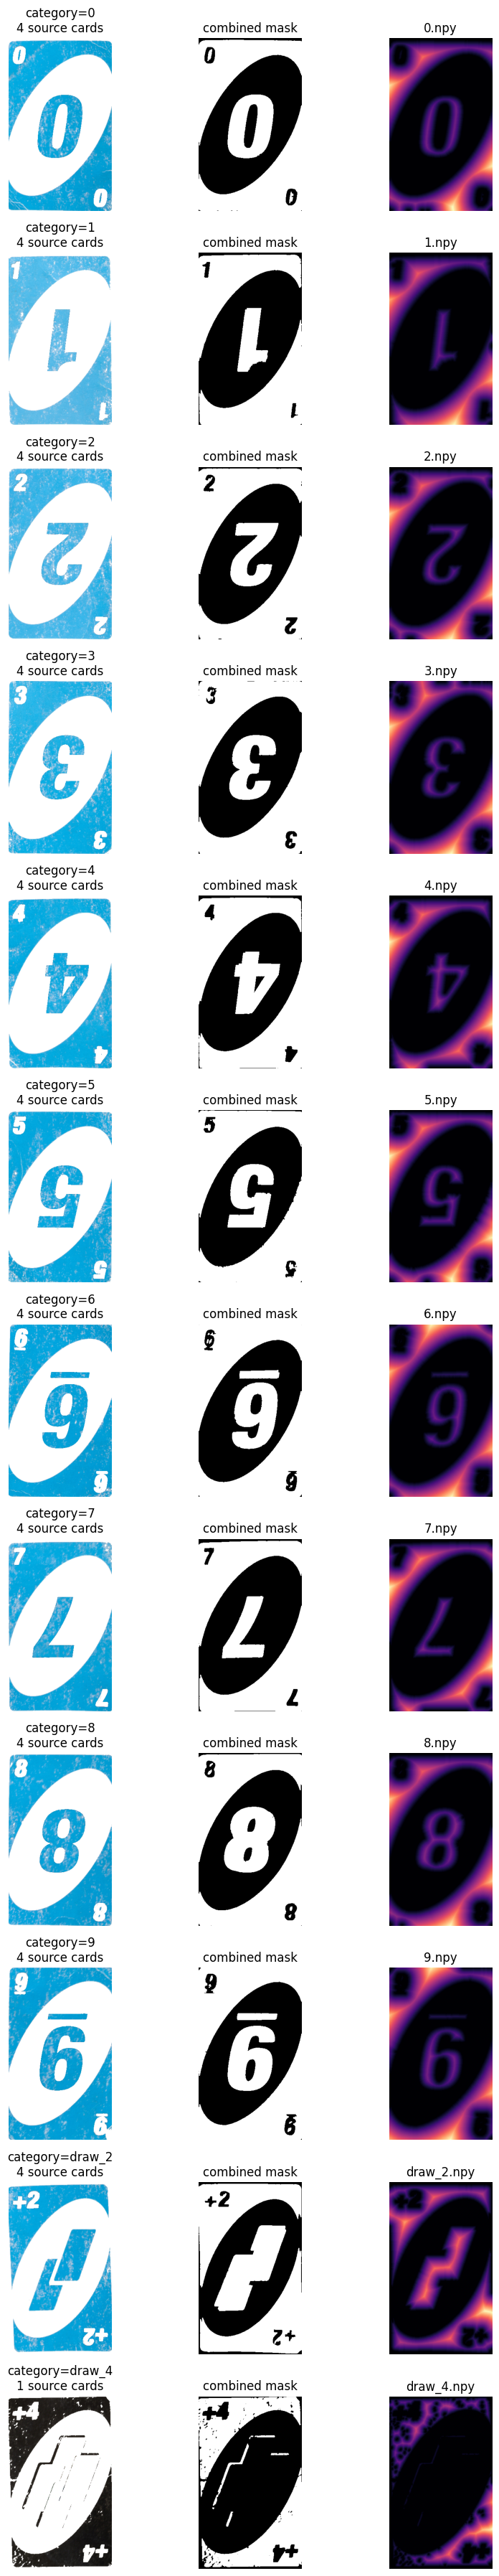

In [5]:
preview_items = saved[:12]
if not preview_items:
    print("No distance maps to preview.")
else:
    fig, axes = plt.subplots(len(preview_items), 3, figsize=(9, 3 * len(preview_items)))
    axes = np.array(axes).reshape(len(preview_items), 3)
    for row, (category, paths, mask, distance_map, output_base) in zip(axes, preview_items):
        image_rgb = cv2.cvtColor(cv2.imread(str(paths[0])), cv2.COLOR_BGR2RGB)
        row[0].imshow(image_rgb)
        row[0].set_title(f"category={category}\n{len(paths)} source cards")
        row[1].imshow(mask, cmap="gray")
        row[1].set_title("combined mask")
        row[2].imshow(distance_map, cmap="magma")
        row[2].set_title(output_base.with_suffix(".npy").name)
        for ax in row:
            ax.axis("off")
    plt.tight_layout()
    plt.show()
